# Final Model Training

This notebook trains the final production model on the complete dataset (training + validation) and prepares it for deployment.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_DIR = Path('../data/flowers')
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

Using device: cpu


In [2]:
# Prepare combined dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Load training and validation datasets
train_dataset = ImageFolder(root=DATA_DIR / 'train', transform=train_transform)
val_dataset = ImageFolder(root=DATA_DIR / 'train', transform=test_transform)  # Use train dir for combined
test_dataset = ImageFolder(root=DATA_DIR / 'test', transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Total training data: {len(train_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Training samples: 1020
Test samples: 6149
Total training data: 1020
Number of classes: 102


In [3]:
# Create final model
def create_final_model(num_classes=102):
    """Create the final ResNet50 model with fine-tuning capability"""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # Initially freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace final layer
    model.fc = nn.Linear(2048, num_classes)
    
    return model

model = create_final_model()
model = model.to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters (initial): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Total parameters: 23,717,030
Trainable parameters (initial): 208,998


In [4]:
# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 32
Test batches: 193


In [5]:
# Training setup
criterion = nn.CrossEntropyLoss()

# Phase 1: Train only the classifier head
optimizer_phase1 = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler_phase1 = optim.lr_scheduler.StepLR(optimizer_phase1, step_size=5, gamma=0.1)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

In [6]:
# Phase 1: Train classifier head
print("Phase 1: Training classifier head...")
print("=" * 50)

num_epochs_phase1 = 10
phase1_train_losses = []
phase1_test_accs = []

for epoch in range(num_epochs_phase1):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_phase1, device)
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    
    scheduler_phase1.step()
    
    phase1_train_losses.append(train_loss)
    phase1_test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs_phase1} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, "
          f"Time: {time.time()-start_time:.2f}s")

print(f"\nPhase 1 complete! Best test accuracy: {max(phase1_test_accs):.4f}")

Phase 1: Training classifier head...
Epoch 1/10 - Train Loss: 4.7764, Train Acc: 0.0637, Test Loss: 3.8413, Test Acc: 0.1657, Time: 1854.19s
Epoch 2/10 - Train Loss: 3.2322, Train Acc: 0.3637, Test Loss: 2.9623, Test Acc: 0.4123, Time: 2003.80s
Epoch 3/10 - Train Loss: 2.3518, Train Acc: 0.5804, Test Loss: 2.3345, Test Acc: 0.5274, Time: 1538.67s
Epoch 4/10 - Train Loss: 1.7529, Train Acc: 0.7069, Test Loss: 1.9195, Test Acc: 0.6170, Time: 1493.47s
Epoch 5/10 - Train Loss: 1.3423, Train Acc: 0.7853, Test Loss: 1.5864, Test Acc: 0.6904, Time: 1922.30s
Epoch 6/10 - Train Loss: 1.0701, Train Acc: 0.8667, Test Loss: 1.4857, Test Acc: 0.7448, Time: 1827.47s
Epoch 7/10 - Train Loss: 0.9778, Train Acc: 0.9020, Test Loss: 1.4548, Test Acc: 0.7548, Time: 1756.88s
Epoch 8/10 - Train Loss: 0.9391, Train Acc: 0.9304, Test Loss: 1.4300, Test Acc: 0.7509, Time: 1499.48s
Epoch 9/10 - Train Loss: 0.9254, Train Acc: 0.9304, Test Loss: 1.4223, Test Acc: 0.7565, Time: 2067.10s
Epoch 10/10 - Train Loss: 0

In [7]:
# Phase 2: Fine-tune some layers
print("\nPhase 2: Fine-tuning selected layers...")
print("=" * 50)

# Unfreeze last two residual blocks
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.layer3.parameters():
    param.requires_grad = True

print(f"Trainable parameters after unfreezing: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Lower learning rate for fine-tuning
optimizer_phase2 = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 0.001},
    {'params': model.layer4.parameters(), 'lr': 0.0001},
    {'params': model.layer3.parameters(), 'lr': 0.0001}
])

scheduler_phase2 = optim.lr_scheduler.StepLR(optimizer_phase2, step_size=5, gamma=0.1)

num_epochs_phase2 = 10
phase2_train_losses = []
phase2_test_accs = []

for epoch in range(num_epochs_phase2):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_phase2, device)
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    
    scheduler_phase2.step()
    
    phase2_train_losses.append(train_loss)
    phase2_test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs_phase2} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, "
          f"Time: {time.time()-start_time:.2f}s")

print(f"\nPhase 2 complete! Best test accuracy: {max(phase2_test_accs):.4f}")


Phase 2: Fine-tuning selected layers...
Trainable parameters after unfreezing: 22,272,102
Epoch 1/10 - Train Loss: 0.9995, Train Acc: 0.7627, Test Loss: 0.8506, Test Acc: 0.7660, Time: 2332.73s
Epoch 2/10 - Train Loss: 0.3057, Train Acc: 0.9304, Test Loss: 0.6898, Test Acc: 0.8099, Time: 2238.83s
Epoch 3/10 - Train Loss: 0.1154, Train Acc: 0.9863, Test Loss: 0.5627, Test Acc: 0.8479, Time: 1870.21s
Epoch 4/10 - Train Loss: 0.0741, Train Acc: 0.9902, Test Loss: 0.5091, Test Acc: 0.8618, Time: 1570.85s
Epoch 5/10 - Train Loss: 0.0426, Train Acc: 0.9931, Test Loss: 0.5364, Test Acc: 0.8584, Time: 2764.97s
Epoch 6/10 - Train Loss: 0.0318, Train Acc: 0.9951, Test Loss: 0.4736, Test Acc: 0.8764, Time: 1801.32s
Epoch 7/10 - Train Loss: 0.0232, Train Acc: 0.9980, Test Loss: 0.4294, Test Acc: 0.8866, Time: 2314.22s
Epoch 8/10 - Train Loss: 0.0181, Train Acc: 1.0000, Test Loss: 0.4296, Test Acc: 0.8853, Time: 2937.83s
Epoch 9/10 - Train Loss: 0.0180, Train Acc: 0.9980, Test Loss: 0.4110, Test A

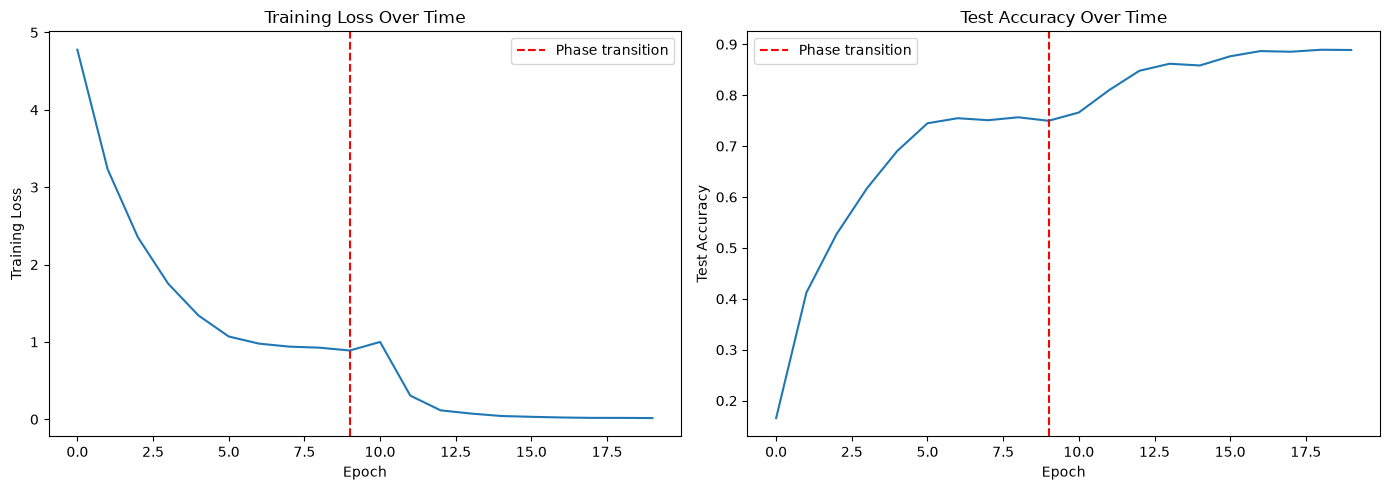

In [8]:
# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

all_train_losses = phase1_train_losses + phase2_train_losses
all_test_accs = phase1_test_accs + phase2_test_accs

ax1.plot(all_train_losses)
ax1.axvline(x=num_epochs_phase1-1, color='r', linestyle='--', label='Phase transition')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Over Time')
ax1.legend()

ax2.plot(all_test_accs)
ax2.axvline(x=num_epochs_phase1-1, color='r', linestyle='--', label='Phase transition')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy Over Time')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# Save final model
torch.save(model.state_dict(), '../models/resnet50_flowers102_final.pth')
print("Final model saved successfully!")

# Save model metadata
metadata = {
    'model_name': 'ResNet50',
    'architecture': 'ResNet50',
    'pretrained': 'ImageNet',
    'dataset': 'Oxford 102 Flowers',
    'num_classes': 102,
    'input_size': [3, 224, 224],
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
    'training_phases': [
        {'phase': 1, 'epochs': num_epochs_phase1, 'learning_rate': 0.001, 'trainable': 'classifier_head'},
        {'phase': 2, 'epochs': num_epochs_phase2, 'learning_rate': 0.0001, 'trainable': 'last_two_blocks'}
    ],
    'best_test_accuracy': max(all_test_accs),
    'final_test_accuracy': all_test_accs[-1]
}

with open('../models/final_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Model metadata saved successfully!")
print("\nFinal Model Summary:")
print(f"  Best Test Accuracy: {max(all_test_accs):.4f}")
print(f"  Final Test Accuracy: {all_test_accs[-1]:.4f}")

Final model saved successfully!
Model metadata saved successfully!

Final Model Summary:
  Best Test Accuracy: 0.8893
  Final Test Accuracy: 0.8888


In [10]:
# Final validation on test set
model.eval()
correct = 0
total = 0
class_correct = [0] * 102
class_total = [0] * 102

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

print(f"\nFinal Test Results:")
print(f"  Overall Accuracy: {correct/total:.4f}")
print(f"  Total test samples: {total}")

# Find best and worst performing classes
class_accuracies = [class_correct[i]/class_total[i] if class_total[i] > 0 else 0 for i in range(102)]
best_classes = sorted(range(102), key=lambda x: class_accuracies[x], reverse=True)[:5]
worst_classes = sorted(range(102), key=lambda x: class_accuracies[x])[:5]

print("\n  Best performing classes:")
for cls in best_classes:
    print(f"    Class {cls}: {class_accuracies[cls]:.4f}")

print("\n  Worst performing classes:")
for cls in worst_classes:
    print(f"    Class {cls}: {class_accuracies[cls]:.4f}")

print("\n" + "=" * 60)
print("FINAL MODEL TRAINING COMPLETE")
print("=" * 60)
print("Model is ready for deployment!")
print(f"Model saved to: ../models/resnet50_flowers102_final.pth")
print("=" * 60)


Final Test Results:
  Overall Accuracy: 0.8888
  Total test samples: 6149

  Best performing classes:
    Class 1: 1.0000
    Class 7: 1.0000
    Class 8: 1.0000
    Class 14: 1.0000
    Class 15: 1.0000

  Worst performing classes:
    Class 36: 0.3056
    Class 25: 0.6000
    Class 49: 0.6092
    Class 74: 0.6093
    Class 21: 0.6667

FINAL MODEL TRAINING COMPLETE
Model is ready for deployment!
Model saved to: ../models/resnet50_flowers102_final.pth
